# 💎 Diamond Price Prediction — Linear Regression vs. Support Vector Regression (SVR)

**🇹🇷 Türkçe:**
Bu notebook, elmas fiyatlarını tahmin etmek için önce bir taban çizgisi (baseline) olarak Doğrusal Regresyon, ardından `GridSearchCV` ile hiperparametre optimizasyonu yapılmış bir Destek Vektör Regresyonu (SVR) modelini karşılaştırıyor. ~54.000 satırlık elmas veri seti kullanılıyor; veri temizleme, aykırı değer temizliği, kategorik kodlama ve özellik ölçekleme adımlarını da içeriyor.

**🇬🇧 English:**
This notebook predicts diamond prices, first with a Linear Regression baseline and then with a hyperparameter-tuned Support Vector Regression (SVR) model via `GridSearchCV`. It uses the ~54,000-row diamonds dataset and covers data cleaning, outlier removal, categorical encoding, and feature scaling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 📥 1. Veri Setini Yükleme / Load the Dataset

**🇹🇷 Türkçe:**
Klasik elmas veri seti (`10-diamonds.csv`) yükleniyor. Bu veri seti; karat, kesim, renk, berraklık gibi elmas özellikleriyle fiyat arasındaki ilişkiyi içeriyor.

**🇬🇧 English:**
The classic diamonds dataset (`10-diamonds.csv`) is loaded. It contains diamond attributes such as carat, cut, color, and clarity alongside price.

In [2]:
df = pd.read_csv("../../Data/10-diamonds.csv")

In [3]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [4]:
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


## 🧹 2. Veri Temizleme / Data Cleaning

**🇹🇷 Türkçe:**
Kopya (`duplicate`) satırlar kaldırılıyor ve eksik değerler kontrol ediliyor. Ardından `x`, `y`, `z` (boyut) kolonlarındaki `0` değerleri fiziksel olarak imkansız olduğu için eksik değer (`NaN`) olarak işaretleniyor.

**🇬🇧 English:**
Duplicate rows are removed and missing values are checked. Then, `0` values in the `x`, `y`, `z` (dimension) columns — which are physically impossible for a diamond — are marked as missing (`NaN`).

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

In [7]:
df.describe()

,carat,depth,table,price,x,y,z
count,53794.00000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000,53794.000000
mean,0.79778,61.748080,57.458109,3933.065082,5.731214,5.734653,3.538714
std,0.47339,1.429909,2.233679,3988.114460,1.120695,1.141209,0.705037
min,0.20000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.40000,61.000000,56.000000,951.000000,4.710000,4.720000,2.910000
50%,0.70000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.04000,62.500000,59.000000,5326.750000,6.540000,6.540000,4.030000
max,5.01000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [8]:
df[["x", "y", "z"]] = df[["x", "y", "z"]].replace(0, np.nan)

## 📊 3. Aykırı Değerlerin Görselleştirilmesi / Visualizing Outliers

**🇹🇷 Türkçe:**
Sayısal özniteliklerin (`x`, `y`, `z`, `depth`, `table`) fiyatla ilişkisi saçılım grafikleriyle inceleniyor. Bu grafikler, veri girişi hatalarından kaynaklanan aşırı uç (aykırı) değerleri gözle tespit etmemizi sağlıyor.

**🇬🇧 English:**
The relationship between numeric features (`x`, `y`, `z`, `depth`, `table`) and price is examined with scatter plots. These plots make it possible to visually spot extreme outliers caused by data-entry errors.

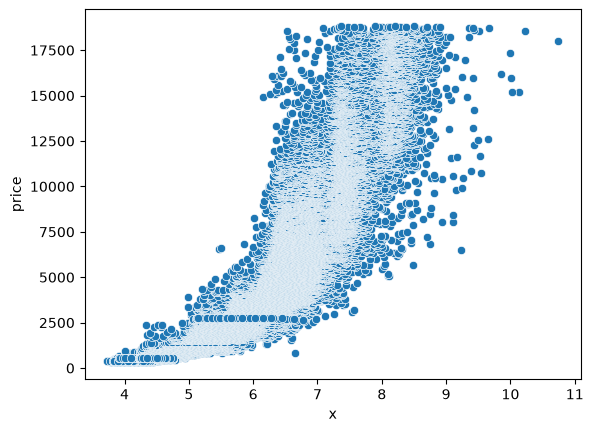

In [9]:
sns.scatterplot(x=df["x"], y=df["price"])
plt.show()

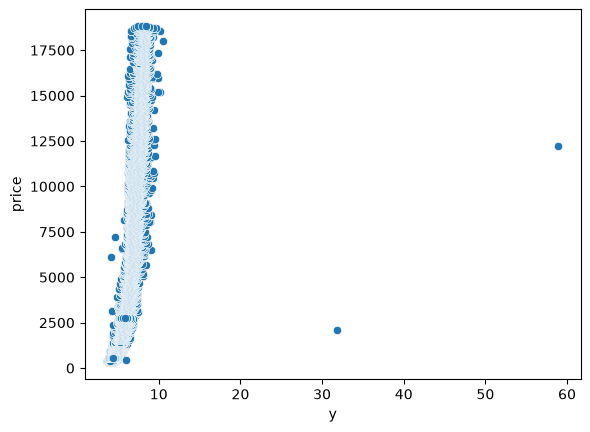

In [10]:
sns.scatterplot(x=df["y"], y=df["price"])
plt.show()

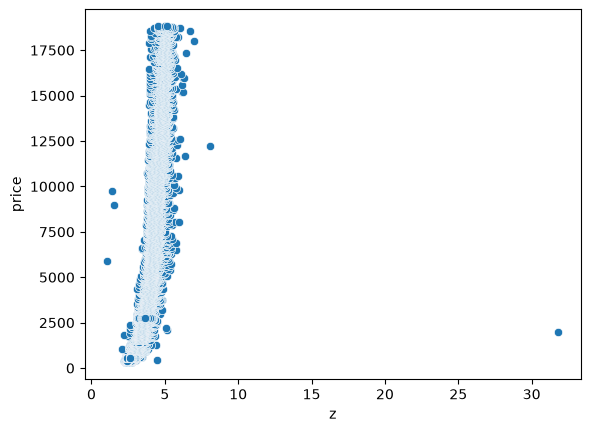

In [11]:
sns.scatterplot(x=df["z"], y=df["price"])
plt.show()

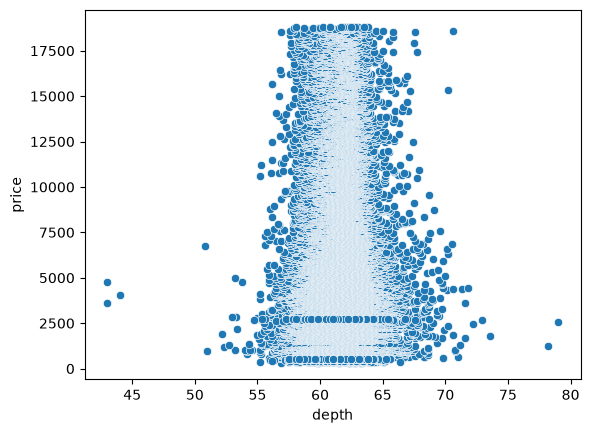

In [12]:
sns.scatterplot(x=df["depth"], y=df["price"])
plt.show()

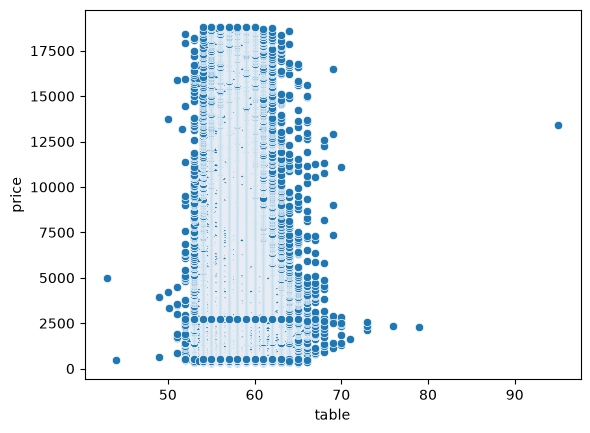

In [13]:
sns.scatterplot(x=df["table"], y=df["price"])
plt.show()

## ✂️ 4. Aykırı Değerlerin Temizlenmesi / Removing Outliers

**🇹🇷 Türkçe:**
Saçılım grafiklerinde görülen mantık dışı değerler (örneğin çok uç `table`/`depth` oranları veya sıfıra yakın `y`/`z` ölçüleri) makul aralıklarla filtreleniyor.

**🇬🇧 English:**
The implausible values seen in the scatter plots (e.g. extreme `table`/`depth` ratios or near-zero `y`/`z` measurements) are filtered out to a reasonable range.

In [14]:
df = df[(df["depth"]<75)&(df["depth"]>45)]
df = df[(df["table"]<80)&(df["table"]>40)]
df = df[(df["y"]<30)]
df = df[(df["z"]<30)&(df["z"]>2)]

## 🎯 5. Öznitelik/Hedef ve Eğitim/Test Ayrımı / Feature/Target and Train/Test Split

**🇹🇷 Türkçe:**
Hedef değişken (`price`) diğer özniteliklerden ayrılıyor, ardından veri %75 eğitim / %25 test olacak şekilde bölünüyor.

**🇬🇧 English:**
The target variable (`price`) is separated from the other features, then the data is split into 75% training / 25% test sets.

In [15]:
X= df.drop(["price"],axis =1)
y= df["price"]

In [16]:
from sklearn.model_selection import train_test_split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 15)

## 🔤 6. Kategorik Değişkenlerin Kodlanması / Encoding Categorical Features

**🇹🇷 Türkçe:**
`cut`, `color`, `clarity` metin (kategorik) kolonları `LabelEncoder` ile sayısal değerlere dönüştürülüyor. Veri sızıntısını (`data leakage`) önlemek için kodlayıcı yalnızca eğitim setine `fit` ediliyor, test setine ise sadece `transform` uygulanıyor.

**🇬🇧 English:**
The text (categorical) columns `cut`, `color`, and `clarity` are converted to numeric values with `LabelEncoder`. To avoid data leakage, the encoder is only `fit` on the training set and merely `transform`ed on the test set.

In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
label_encoder = LabelEncoder()

In [20]:
for col in ['cut', 'color', 'clarity']:
    X_train[col] = label_encoder.fit_transform(X_train[col])
    X_test[col] = label_encoder.transform(X_test[col])

## 📏 7. Özellik Ölçekleme / Feature Scaling

**🇹🇷 Türkçe:**
SVR gibi mesafeye dayalı algoritmalar, farklı ölçeklerdeki özniteliklerden olumsuz etkilenir. `StandardScaler` ile tüm öznitelikler ortalaması 0, standart sapması 1 olacak şekilde ölçekleniyor; veri sızıntısını önlemek için ölçekleyici yalnızca eğitim setine `fit` ediliyor.

**🇬🇧 English:**
Distance-based algorithms like SVR are sensitive to features on different scales. `StandardScaler` rescales all features to zero mean and unit variance; to avoid data leakage, the scaler is only `fit` on the training set.

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

## 📈 8. Taban Çizgisi Modeli: Doğrusal Regresyon / Baseline Model: Linear Regression

**🇹🇷 Türkçe:**
SVR'ye geçmeden önce, karşılaştırma için basit bir Doğrusal Regresyon modeli eğitilip Ortalama Mutlak Hata (`MAE`) ve `R²` skoru ile değerlendiriliyor.

**🇬🇧 English:**
Before moving to SVR, a simple Linear Regression model is trained as a baseline for comparison and evaluated with Mean Absolute Error (`MAE`) and `R²` score.

Mean absolute error 856.4786881226602
R2 Score 0.8872007493425477


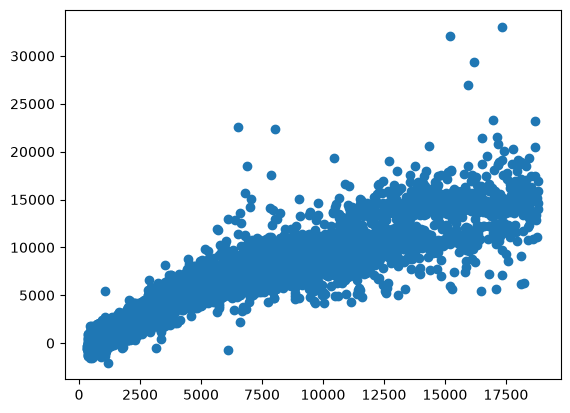

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
linreg=LinearRegression()
linreg.fit(X_train_scaled,y_train)
y_pred=linreg.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)
plt.show()

## 🧮 9. Destek Vektör Regresyonu (SVR) / Support Vector Regression (SVR)

**🇹🇷 Türkçe:**
Şimdi, doğrusal olmayan ilişkileri yakalayabilen çekirdek tabanlı bir regresyon algoritması olan SVR deneniyor.

**🇬🇧 English:**
Now, SVR — a kernel-based regression algorithm capable of capturing non-linear relationships — is tried.

In [24]:
from sklearn.svm import SVR
svr=SVR()

## 🎛️ 10. Hiperparametre Optimizasyonu / Hyperparameter Tuning

**🇹🇷 Türkçe:**
`C`, `gamma` ve `kernel` parametrelerinin en iyi kombinasyonunu bulmak için `GridSearchCV` ile 5 katlamalı çapraz doğrulama kullanılıyor.

**🇬🇧 English:**
`GridSearchCV` with 5-fold cross-validation is used to find the best combination of the `C`, `gamma`, and `kernel` parameters.

In [25]:
## Hyperparameter Tuning using GridSearch CV
from sklearn.model_selection import GridSearchCV

# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf','linear']}

In [26]:
grid = GridSearchCV(SVR(), param_grid, refit = True,verbose = 3,n_jobs=-1) # n_jobs=-1 means use all processor

## ⚠️ `grid.fit` Neden Çok Uzun Sürüyor? / Why Does `grid.fit` Take So Long?

**🇹🇷 Türkçe:**
**Hata:** `grid.fit(X_train_scaled, y_train)` doğrudan tüm eğitim setiyle (~40.000 satır) çalıştırıldığında pratikte bitmiyor. Sebebi, scikit-learn'ün `SVR` sınıfının arka planda kullandığı `libsvm` kütüphanesinin eğitim süresinin örnek sayısıyla **karesel/kübik** olarak artmasıdır (O(n²)–O(n³)). Burada 5 kat × 50 parametre kombinasyonu = 250 ayrı model eğitimi yapılıyor; her biri onlarca saniye sürse bile toplam süre saatleri, hatta günleri bulabilir. (Test olarak tek bir `SVR(C=1000, gamma=1).fit()` çağrısı tüm eğitim setinde 60 saniyede bile tamamlanmadı.)

**Çözüm:** `GridSearchCV`'yi tüm veri yerine, eğitim setinden rastgele seçilmiş küçük bir örneklem (`sample`) üzerinde çalıştırıyoruz. Bu, kernel tabanlı SVM'lerle büyük veri setlerinde hiperparametre araması yaparken yaygın kullanılan pratik bir yöntemdir — arama hızını büyük ölçüde artırırken en iyi parametrelerin bulunmasını hâlâ mümkün kılar.

**🇬🇧 English:**
**Bug:** running `grid.fit(X_train_scaled, y_train)` directly on the full training set (~40,000 rows) never practically finishes. The reason is that scikit-learn's `SVR`, backed by the `libsvm` library, has a training time that grows **quadratically to cubically** with the number of samples (O(n²)–O(n³)). Here, 5 folds × 50 parameter combinations means 250 separate model fits; even if each one took tens of seconds, the total could stretch into hours or days. (As a test, a single `SVR(C=1000, gamma=1).fit()` call on the full training set didn't even finish within 60 seconds.)

**Fix:** `GridSearchCV` is run on a small random sample drawn from the training set instead of the full data. This is a common, practical technique when tuning kernel-based SVMs on large datasets — it dramatically speeds up the search while still finding good hyperparameters.

In [27]:
# Grid search büyük veri setinde çok yavaş olduğu için eğitim setinden rastgele bir örneklem alıyoruz
# GridSearchCV is very slow on the full dataset, so we draw a random sample from the training set
sample_size = 3000
rng = np.random.RandomState(15)
sample_idx = rng.choice(X_train_scaled.shape[0], size=sample_size, replace=False)
X_train_sample = X_train_scaled[sample_idx]
y_train_sample = y_train.iloc[sample_idx]

In [28]:
grid.fit(X_train_sample, y_train_sample)

Fitting 5 folds for each of 50 candidates, totalling 250 fits

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVR()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf', 'linear']}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",3
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFo

## ✅ 11. Test Setinde Değerlendirme / Evaluation on the Test Set

**🇹🇷 Türkçe:**
En iyi parametrelerle bulunan model, örneklemden bağımsız tam test setinde değerlendiriliyor; MAE ve R² skorları Doğrusal Regresyon taban çizgisiyle karşılaştırılabilir.

**🇬🇧 English:**
The model found with the best parameters is evaluated on the full, held-out test set; the MAE and R² scores can be compared against the Linear Regression baseline.

Mean absolute error 548.5177295568304
R2 Score 0.929028589655209


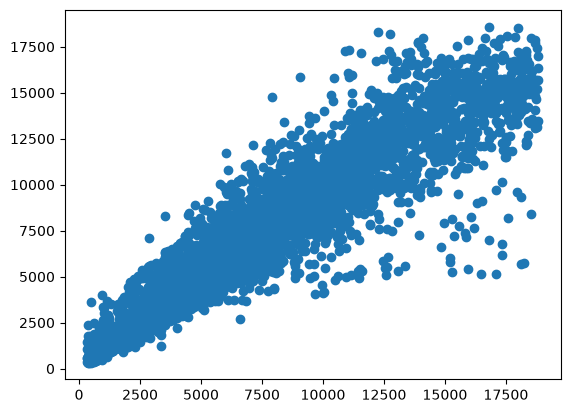

In [29]:
y_pred=grid.predict(X_test_scaled)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print("Mean absolute error", mae)
print("R2 Score", score)
plt.scatter(y_test,y_pred)
plt.show()

## 🏁 Sonuç / Conclusion

**🇹🇷 Türkçe:**
Bu notebook, elmas fiyatlarını tahmin etmek için Doğrusal Regresyon ile hiperparametreleri ayarlanmış SVR'yi karşılaştırıyor. Ayrıca büyük veri setlerinde çekirdek tabanlı (kernel-based) modellerle hiperparametre araması yaparken karşılaşılan yaygın bir performans tuzağını (`GridSearchCV`'nin tüm veriyle çalıştırılması) ve pratik çözümünü (eğitim öncesi örnekleme) gösteriyor.

Beğendiyseniz bir upvote sevindirir! 🙌

**🇬🇧 English:**
This notebook compares Linear Regression against a hyperparameter-tuned SVR for predicting diamond prices. It also demonstrates a common performance pitfall when tuning kernel-based models on large datasets (running `GridSearchCV` on the full data) and its practical fix (sampling before the search).

If you found this useful, an upvote is appreciated! 🙌